
# Publication Plots — Sleep Stage Prediction

This notebook generates paper-ready figures from the finalized Sleep-EDF feature dataset and the finalized experiment results.

**Input files**
- `sleep_edf_features.csv`
- `participant_split.csv`

**Final experimental configuration**
- 5 classes: W, N1, N2, N3, REM
- 10 spectral features
- 30-second epochs
- sequence length: 10 epochs (5 minutes)
- stacked LSTM: 32 + 32 units
- dropout: 0.30
- participant-level split: 70 / 15 / 15 participants
- final test evaluation: seeds 42, 123, 456

The notebook saves figures as both PNG (300 dpi) and PDF in `paper_figures/`.


In [3]:

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Paths
DATA_DIR = Path('../data/features')
FEATURES_PATH = DATA_DIR / 'sleep_edf_features.csv'
SPLIT_PATH = DATA_DIR / 'participant_split.csv'
FIG_DIR = DATA_DIR / 'paper_figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Global plotting defaults (publication-friendly, no seaborn)
plt.rcParams.update({
    'figure.dpi': 120,
    'savefig.dpi': 300,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 9,
    'figure.constrained_layout.use': True,
})

STAGES = ['W', 'N1', 'N2', 'N3', 'REM']
COLORS = {
    'W': '#4C78A8', 'N1': '#F58518', 'N2': '#54A24B',
    'N3': '#E45756', 'REM': '#B279A2'
}

def savefig(name):
    fig = plt.gcf()
    fig.savefig(FIG_DIR / f'{name}.png', bbox_inches='tight')
    fig.savefig(FIG_DIR / f'{name}.pdf', bbox_inches='tight')
    print(f'Saved: {FIG_DIR / name}.png')
    print(f'Saved: {FIG_DIR / name}.pdf')


In [4]:
# Load data
features = pd.read_csv(FEATURES_PATH)
splits = pd.read_csv(SPLIT_PATH)

# Normalize IDs. A recording such as SC4001 belongs to participant SC400.
features['subject_id'] = features['subject_id'].astype(str)
splits['participant_id'] = splits['participant_id'].astype(str)
features['participant_id'] = features['subject_id'].str[:5]

# Normalize split naming used in the CSV (val -> validation).
splits['split'] = splits['split'].replace({'val': 'validation'})

# Add train/validation/test label to every feature row.
features = features.merge(
    splits[['participant_id', 'split']],
    on='participant_id', how='left', validate='many_to_one'
).drop(columns=['participant_id'])

assert features['split'].notna().all(), 'Some recordings do not have a split assignment.'
assert set(features['split'].unique()) <= {'train', 'validation', 'test'}
assert set(features['target_stage'].dropna().unique()) <= set(STAGES)

print('Feature rows:', f'{len(features):,}')
print('Recordings:', features['subject_id'].nunique())
print('Participants:', splits['participant_id'].nunique())
print('Participant split counts:')
print(splits['split'].value_counts().reindex(['train', 'validation', 'test']))
print('\nEpoch counts by split:')
print(features['split'].value_counts().reindex(['train', 'validation', 'test']))
print('\nClass counts:')
print(features['target_stage'].value_counts().reindex(STAGES).to_frame('count'))

Feature rows: 457,577
Recordings: 197
Participants: 100
Participant split counts:
split
train         70
validation    15
test          15
Name: count, dtype: int64

Epoch counts by split:
split
train         321688
validation     65736
test           70153
Name: count, dtype: int64

Class counts:
               count
target_stage        
W             289781
N1             25175
N2             88983
N3             19454
REM            34184


## Figure 1 — Overall class distribution

Saved: ..\data\features\paper_figures\fig01_class_distribution.png
Saved: ..\data\features\paper_figures\fig01_class_distribution.pdf


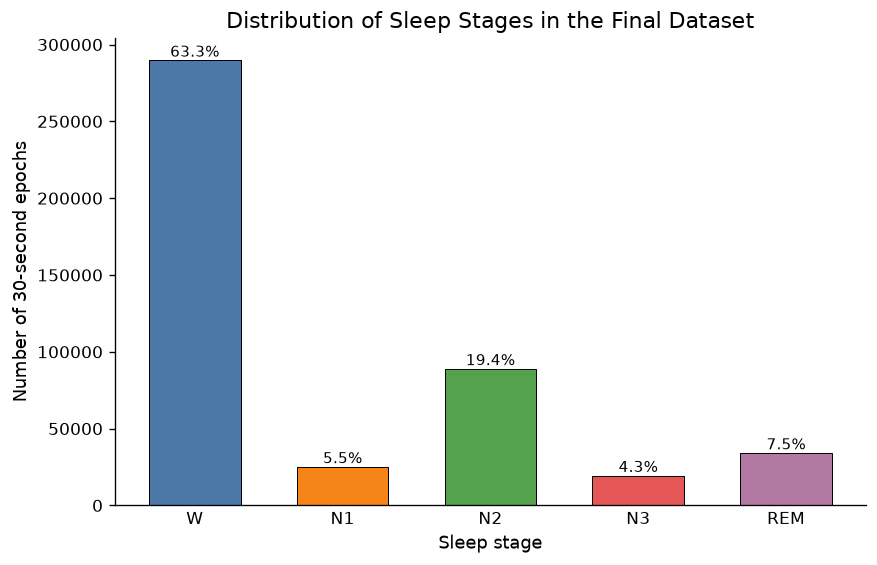

In [5]:

counts = features['target_stage'].value_counts().reindex(STAGES)
perc = counts / counts.sum() * 100

fig, ax = plt.subplots(figsize=(7.2, 4.6))
bars = ax.bar(STAGES, counts.values, width=0.62,
              color=[COLORS[s] for s in STAGES], edgecolor='black', linewidth=0.6)
ax.set_xlabel('Sleep stage')
ax.set_ylabel('Number of 30-second epochs')
ax.set_title('Distribution of Sleep Stages in the Final Dataset')
ax.tick_params(axis='x', length=0)
ax.spines[['top', 'right']].set_visible(False)

for bar, p in zip(bars, perc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
            f'{p:.1f}%', ha='center', va='bottom', fontsize=9)

savefig('fig01_class_distribution')
plt.show()


## Figure 2 — Class distribution across train/validation/test

Saved: ..\data\features\paper_figures\fig02_split_class_distribution.png
Saved: ..\data\features\paper_figures\fig02_split_class_distribution.pdf


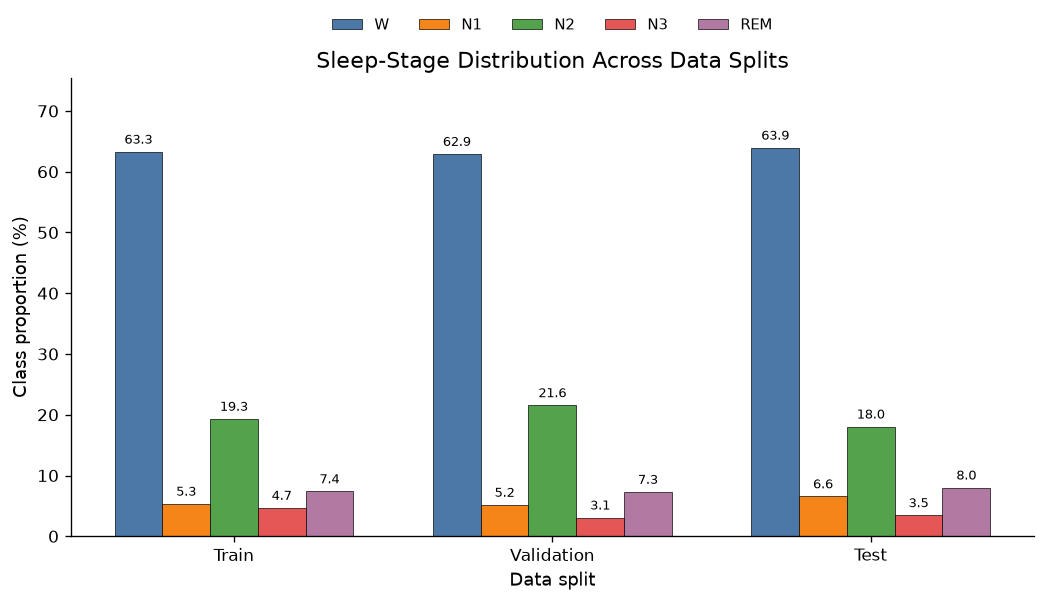

In [6]:
# Class composition of the three data splits.
split_counts = (
    features.groupby(['split', 'target_stage']).size()
    .unstack(fill_value=0)
    .reindex(index=['train', 'validation', 'test'], columns=STAGES)
)
split_pct = split_counts.div(split_counts.sum(axis=1), axis=0) * 100

x = np.arange(len(split_pct.index))
width = 0.15
fig, ax = plt.subplots(figsize=(8.6, 4.9))
for i, stage in enumerate(STAGES):
    vals = split_pct[stage].to_numpy()
    bars = ax.bar(
        x + (i - 2) * width, vals, width=width,
        label=stage, color=COLORS[stage],
        edgecolor='black', linewidth=0.4
    )
    for bar, value in zip(bars, vals):
        ax.text(
            bar.get_x() + bar.get_width()/2, value + 0.8,
            f'{value:.1f}', ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x, ['Train', 'Validation', 'Test'])
ax.set_xlabel('Data split')
ax.set_ylabel('Class proportion (%)')
ax.set_title('Sleep-Stage Distribution Across Data Splits')
ax.legend(ncol=5, frameon=False, loc='upper center', bbox_to_anchor=(0.5, 1.16))
ax.spines[['top', 'right']].set_visible(False)
ax.set_ylim(0, max(split_pct.max()) * 1.18)

savefig('fig02_split_class_distribution')
plt.show()

## Figure 3 — Relative spectral power by sleep stage

Saved: ..\data\features\paper_figures\fig03_relative_band_power.png
Saved: ..\data\features\paper_figures\fig03_relative_band_power.pdf


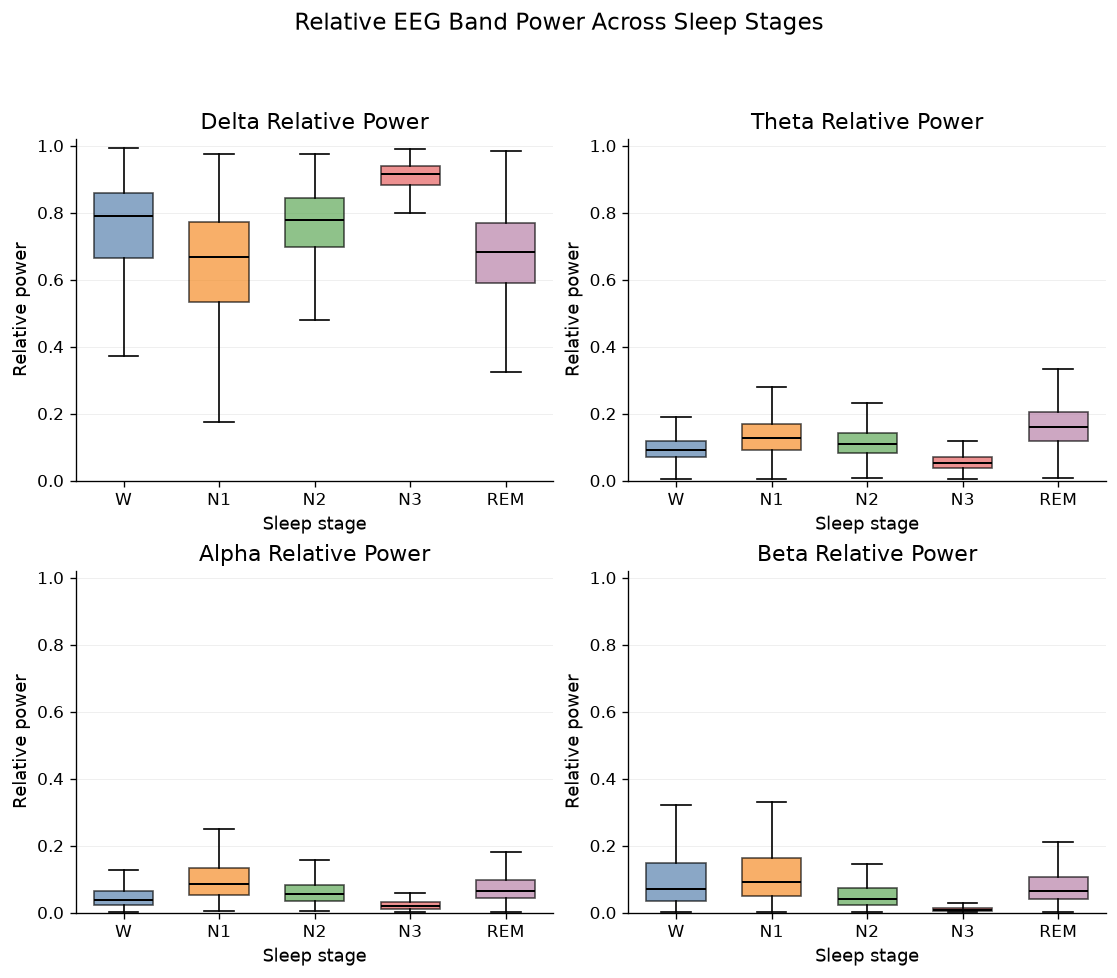

In [9]:
# Distribution of relative EEG band power across sleep stages.
relative_features = [
    'delta_relative', 'theta_relative',
    'alpha_relative', 'beta_relative'
]
labels = ['Delta', 'Theta', 'Alpha', 'Beta']

fig, axes = plt.subplots(2, 2, figsize=(9.2, 7.2), sharey=False)
axes = axes.ravel()

for idx, (ax, feature, label) in enumerate(zip(axes, relative_features, labels)):
    data = [
        features.loc[features['target_stage'] == stage, feature]
        .dropna().to_numpy()
        for stage in STAGES
    ]

    bp = ax.boxplot(
        data,
        tick_labels=STAGES,
        patch_artist=True,
        showfliers=False,
        widths=0.62
    )

    for patch, stage in zip(bp['boxes'], STAGES):
        patch.set_facecolor(COLORS[stage])
        patch.set_alpha(0.65)
        patch.set_edgecolor('black')

    for median in bp['medians']:
        median.set_color('black')
        median.set_linewidth(1.2)

    ax.set_title(f'{label} Relative Power')
    ax.set_xlabel('Sleep stage')
    ax.set_ylabel('Relative power')
    ax.set_ylim(0, 1.02)
    ax.grid(axis='y', alpha=0.2, linewidth=0.6)
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('Relative EEG Band Power Across Sleep Stages', fontsize=14, y=1.11)
savefig('fig03_relative_band_power')
plt.show()

## Figure 4 — Correlation matrix of the 10 engineered features

Saved: ..\data\features\paper_figures\fig04_feature_correlation.png
Saved: ..\data\features\paper_figures\fig04_feature_correlation.pdf


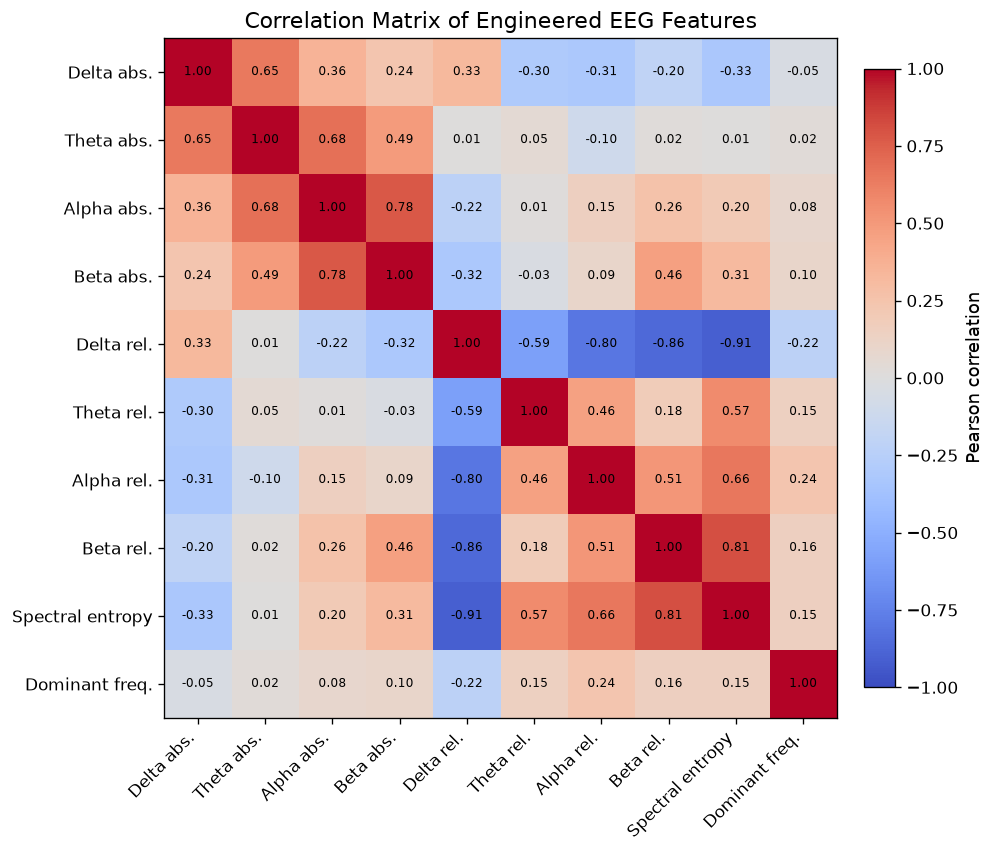

In [10]:

feature_cols = [
    'delta_absolute', 'theta_absolute', 'alpha_absolute', 'beta_absolute',
    'delta_relative', 'theta_relative', 'alpha_relative', 'beta_relative',
    'spectral_entropy', 'dominant_frequency'
]

corr = features[feature_cols].corr()
short_names = [
    'Delta abs.', 'Theta abs.', 'Alpha abs.', 'Beta abs.',
    'Delta rel.', 'Theta rel.', 'Alpha rel.', 'Beta rel.',
    'Spectral entropy', 'Dominant freq.'
]

fig, ax = plt.subplots(figsize=(8.2, 7.0))
im = ax.imshow(corr.values, vmin=-1, vmax=1, cmap='coolwarm', aspect='auto')
ax.set_xticks(np.arange(len(short_names)), short_names, rotation=45, ha='right')
ax.set_yticks(np.arange(len(short_names)), short_names)
ax.set_title('Correlation Matrix of Engineered EEG Features')

# Annotate cells selectively for readability
for i in range(corr.shape[0]):
    for j in range(corr.shape[1]):
        ax.text(j, i, f'{corr.iloc[i, j]:.2f}', ha='center', va='center', fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Pearson correlation')

savefig('fig04_feature_correlation')
plt.show()


## Figure 5 — Validation ablation study: temporal context

Saved: ..\data\features\paper_figures\fig05_context_ablation.png
Saved: ..\data\features\paper_figures\fig05_context_ablation.pdf


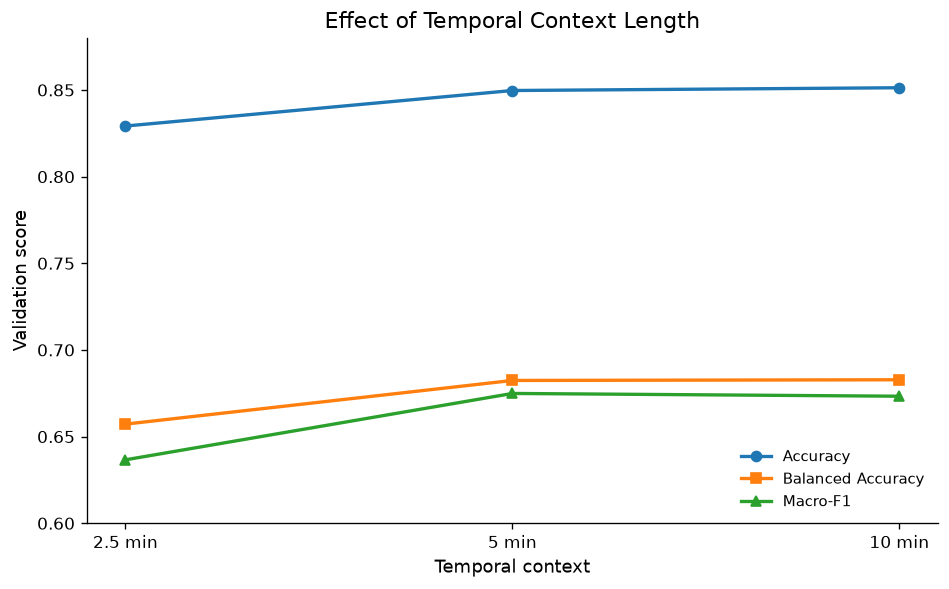

In [11]:

context_results = pd.DataFrame({
    'context': ['2.5 min', '5 min', '10 min'],
    'epochs': [5, 10, 20],
    'accuracy': [0.8292, 0.8497, 0.8513],
    'balanced_accuracy': [0.6572, 0.6824, 0.6828],
    'macro_f1': [0.6366, 0.6749, 0.6733],
})

x = np.arange(len(context_results))
fig, ax = plt.subplots(figsize=(7.8, 4.8))
for metric, label, marker in [
    ('accuracy', 'Accuracy', 'o'),
    ('balanced_accuracy', 'Balanced Accuracy', 's'),
    ('macro_f1', 'Macro-F1', '^'),
]:
    ax.plot(x, context_results[metric], marker=marker, linewidth=2, markersize=6, label=label)

ax.set_xticks(x, context_results['context'])
ax.set_xlabel('Temporal context')
ax.set_ylabel('Validation score')
ax.set_title('Effect of Temporal Context Length')
ax.legend(frameon=False)
ax.set_ylim(0.60, 0.88)
ax.spines[['top', 'right']].set_visible(False)

savefig('fig05_context_ablation')
plt.show()


## Figure 6 — Validation ablation study: loss function

Saved: ..\data\features\paper_figures\fig06_loss_ablation.png
Saved: ..\data\features\paper_figures\fig06_loss_ablation.pdf


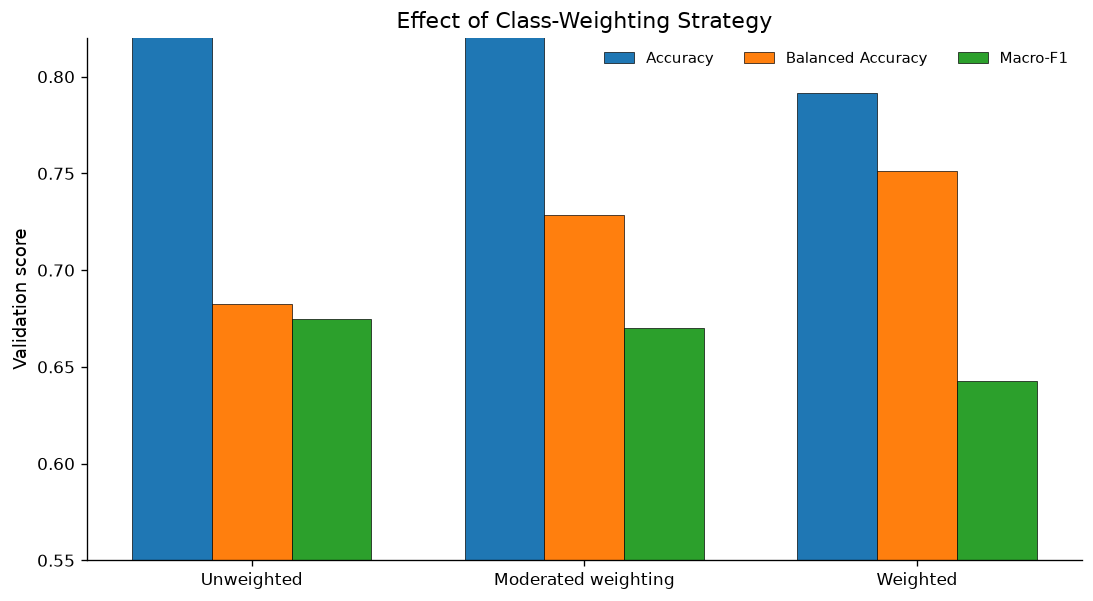

In [18]:

loss_results = pd.DataFrame({
    'loss': ['Unweighted', 'Moderated weighting', 'Weighted'],
    'accuracy': [0.8497, 0.8278, 0.7917],
    'balanced_accuracy': [0.6824, 0.7283, 0.7510],
    'macro_f1': [0.6749, 0.6701, 0.6428],
})

x = np.arange(len(loss_results))
width = 0.24
fig, ax = plt.subplots(figsize=(9.0, 4.9))
for i, (metric, label) in enumerate([
    ('accuracy', 'Accuracy'),
    ('balanced_accuracy', 'Balanced Accuracy'),
    ('macro_f1', 'Macro-F1'),
]):
    ax.bar(x + (i - 1) * width, loss_results[metric], width=width,
           label=label, edgecolor='black', linewidth=0.4)

ax.set_xticks(x, loss_results['loss'])
ax.set_ylabel('Validation score')
ax.set_title('Effect of Class-Weighting Strategy')
ax.legend(frameon=False, ncol=3)
ax.set_ylim(0.55, 0.82)
ax.spines[['top', 'right']].set_visible(False)

savefig('fig06_loss_ablation')
plt.show()


## Figure 7 — Validation ablation study: model capacity and architecture

Saved: ..\data\features\paper_figures\fig07_model_ablation.png
Saved: ..\data\features\paper_figures\fig07_model_ablation.pdf


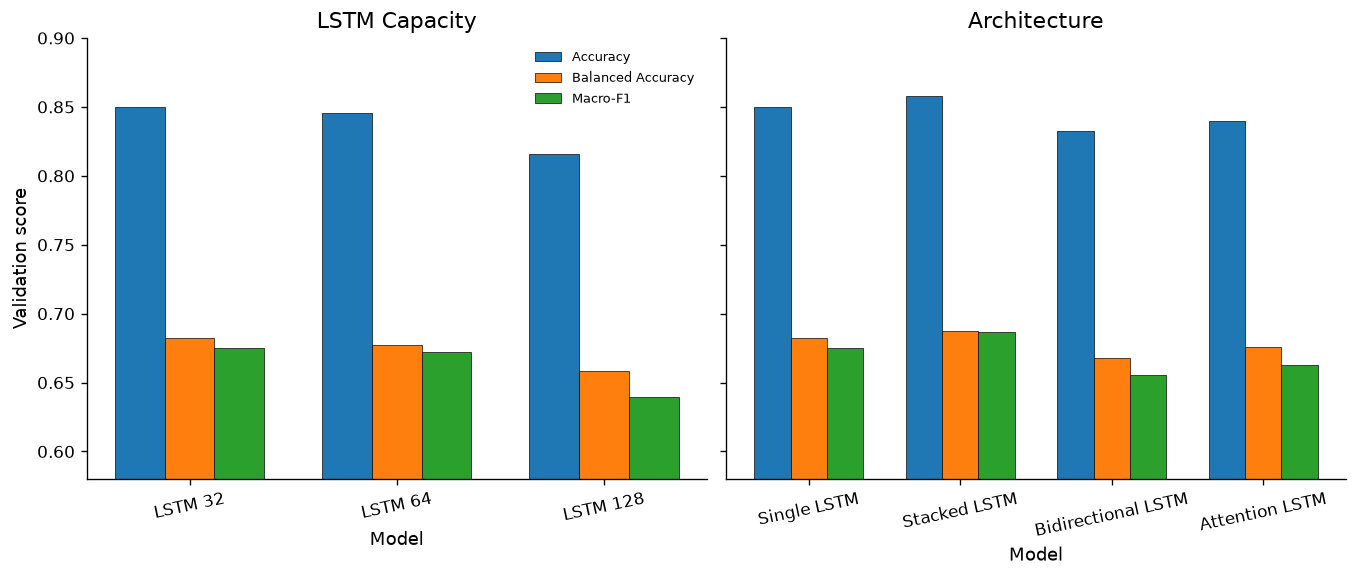

In [19]:

capacity = pd.DataFrame({
    'model': ['LSTM 32', 'LSTM 64', 'LSTM 128'],
    'accuracy': [0.8497, 0.8458, 0.8161],
    'balanced_accuracy': [0.6824, 0.6774, 0.6582],
    'macro_f1': [0.6749, 0.6721, 0.6393],
})
architecture = pd.DataFrame({
    'model': ['Single LSTM', 'Stacked LSTM', 'Bidirectional LSTM', 'Attention LSTM'],
    'accuracy': [0.8497, 0.8577, 0.8324, 0.8401],
    'balanced_accuracy': [0.6824, 0.6875, 0.6681, 0.6760],
    'macro_f1': [0.6749, 0.6869, 0.6554, 0.6627],
})

fig, axes = plt.subplots(1, 2, figsize=(11.2, 4.7), sharey=True)
for ax, df, title in zip(axes, [capacity, architecture], ['LSTM Capacity', 'Architecture']):
    x = np.arange(len(df))
    width = 0.24
    for i, (metric, label) in enumerate([
        ('accuracy', 'Accuracy'),
        ('balanced_accuracy', 'Balanced Accuracy'),
        ('macro_f1', 'Macro-F1'),
    ]):
        ax.bar(x + (i - 1) * width, df[metric], width=width,
               label=label, edgecolor='black', linewidth=0.4)
    ax.set_xticks(x, df['model'], rotation=12)
    ax.set_title(title)
    ax.set_xlabel('Model')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('Validation score')
axes[0].legend(frameon=False, fontsize=8)
axes[0].set_ylim(0.58, 0.90)

savefig('fig07_model_ablation')
plt.show()


## Figure 8 — Final test performance across three random seeds

Saved: ..\data\features\paper_figures\fig08_seed_robustness.png
Saved: ..\data\features\paper_figures\fig08_seed_robustness.pdf


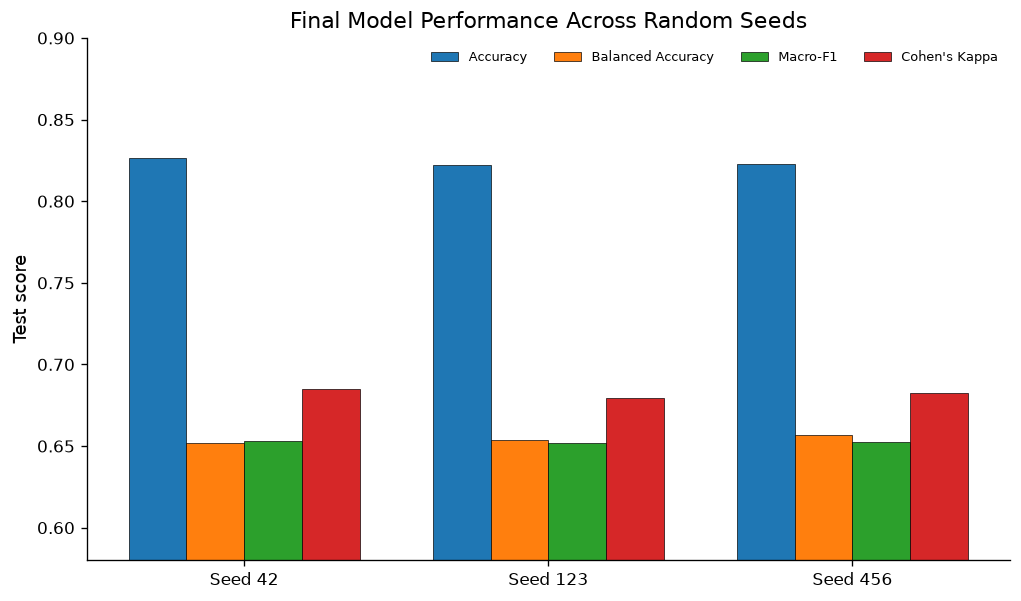

In [20]:

seed_results = pd.DataFrame({
    'seed': [42, 123, 456],
    'accuracy': [0.8266, 0.8224, 0.8230],
    'balanced_accuracy': [0.6517, 0.6537, 0.6565],
    'macro_f1': [0.6534, 0.6520, 0.6524],
    'weighted_f1': [0.8245, 0.8221, 0.8235],
    'kappa': [0.6852, 0.6794, 0.6823],
})

fig, ax = plt.subplots(figsize=(8.4, 4.9))
metrics = [
    ('accuracy', 'Accuracy'),
    ('balanced_accuracy', 'Balanced Accuracy'),
    ('macro_f1', 'Macro-F1'),
    ('kappa', "Cohen's Kappa"),
]
x = np.arange(len(seed_results))
width = 0.19
for i, (metric, label) in enumerate(metrics):
    ax.bar(x + (i - 1.5) * width, seed_results[metric], width=width,
           label=label, edgecolor='black', linewidth=0.4)
ax.set_xticks(x, [f'Seed {s}' for s in seed_results['seed']])
ax.set_ylabel('Test score')
ax.set_title('Final Model Performance Across Random Seeds')
ax.legend(frameon=False, ncol=4, fontsize=8)
ax.set_ylim(0.58, 0.90)
ax.spines[['top', 'right']].set_visible(False)

savefig('fig08_seed_robustness')
plt.show()


## Figure 9 — Final per-stage F1 score

Saved: ..\data\features\paper_figures\fig09_per_stage_f1.png
Saved: ..\data\features\paper_figures\fig09_per_stage_f1.pdf


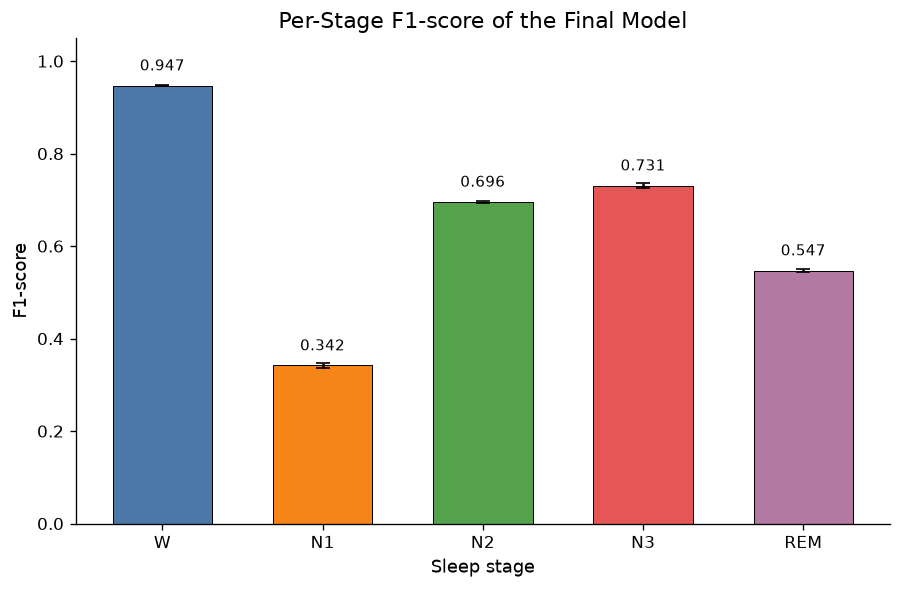

In [21]:

per_stage_f1 = pd.DataFrame({
    'stage': STAGES,
    'f1_mean': [0.9472, 0.3419, 0.6957, 0.7309, 0.5472],
    'f1_std': [0.0013, 0.0045, 0.0027, 0.0045, 0.0023],
})

fig, ax = plt.subplots(figsize=(7.4, 4.8))
x = np.arange(len(per_stage_f1))
ax.bar(x, per_stage_f1['f1_mean'], yerr=per_stage_f1['f1_std'], capsize=4,
       width=0.62, color=[COLORS[s] for s in STAGES], edgecolor='black', linewidth=0.6)
ax.set_xticks(x, STAGES)
ax.set_xlabel('Sleep stage')
ax.set_ylabel('F1-score')
ax.set_title('Per-Stage F1-score of the Final Model')
ax.set_ylim(0, 1.05)
ax.spines[['top', 'right']].set_visible(False)

for i, v in enumerate(per_stage_f1['f1_mean']):
    ax.text(i, v + 0.025, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

savefig('fig09_per_stage_f1')
plt.show()


## Figure 10 — Confusion matrix (seed 42)

Saved: ..\data\features\paper_figures\fig10_confusion_matrix_seed42.png
Saved: ..\data\features\paper_figures\fig10_confusion_matrix_seed42.pdf


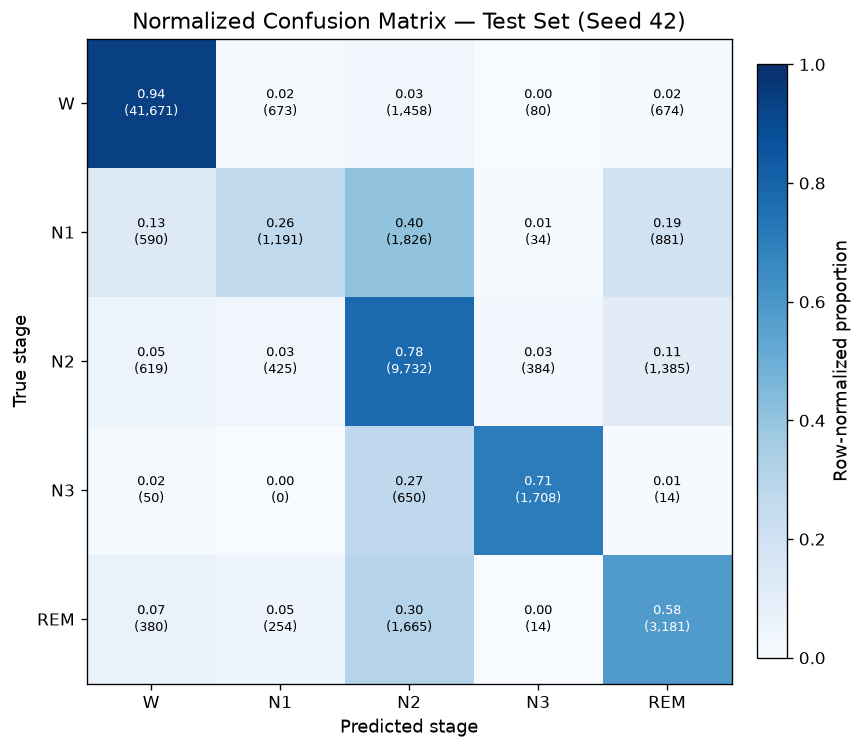

In [22]:

cm = np.array([
    [41671, 673, 1458, 80, 674],
    [590, 1191, 1826, 34, 881],
    [619, 425, 9732, 384, 1385],
    [50, 0, 650, 1708, 14],
    [380, 254, 1665, 14, 3181],
], dtype=int)

cm_norm = cm / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(7.0, 6.2))
im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)
ax.set_xticks(np.arange(5), STAGES)
ax.set_yticks(np.arange(5), STAGES)
ax.set_xlabel('Predicted stage')
ax.set_ylabel('True stage')
ax.set_title('Normalized Confusion Matrix — Test Set (Seed 42)')

for i in range(5):
    for j in range(5):
        value = cm_norm[i, j]
        count = cm[i, j]
        text_color = 'white' if value > 0.55 else 'black'
        ax.text(j, i, f'{value:.2f}\n({count:,})', ha='center', va='center',
                color=text_color, fontsize=8)

cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Row-normalized proportion')

savefig('fig10_confusion_matrix_seed42')
plt.show()


## Figure 11 — One-vs-Rest ROC-AUC by sleep stage

Saved: ..\data\features\paper_figures\fig11_per_stage_roc_auc.png
Saved: ..\data\features\paper_figures\fig11_per_stage_roc_auc.pdf


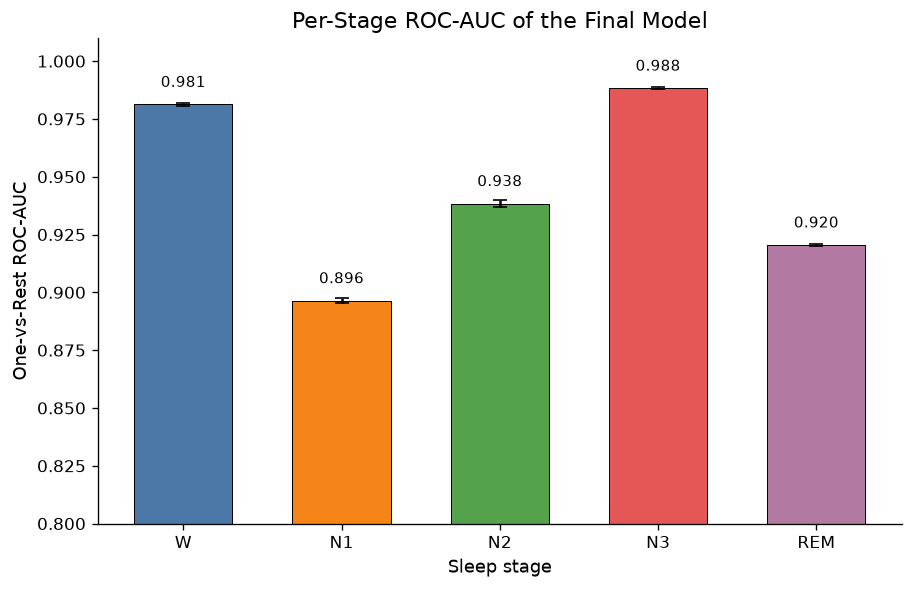

In [23]:

roc_auc = pd.DataFrame({
    'stage': STAGES,
    'auc_mean': [0.9813, 0.8964, 0.9384, 0.9883, 0.9205],
    'auc_std': [0.0007, 0.0010, 0.0015, 0.0003, 0.0006],
})

fig, ax = plt.subplots(figsize=(7.5, 4.8))
x = np.arange(len(roc_auc))
ax.bar(x, roc_auc['auc_mean'], yerr=roc_auc['auc_std'], capsize=4,
       width=0.62, color=[COLORS[s] for s in STAGES], edgecolor='black', linewidth=0.6)
ax.set_xticks(x, STAGES)
ax.set_xlabel('Sleep stage')
ax.set_ylabel('One-vs-Rest ROC-AUC')
ax.set_title('Per-Stage ROC-AUC of the Final Model')
ax.set_ylim(0.80, 1.01)
ax.spines[['top', 'right']].set_visible(False)

for i, v in enumerate(roc_auc['auc_mean']):
    ax.text(i, v + 0.006, f'{v:.3f}', ha='center', va='bottom', fontsize=9)

savefig('fig11_per_stage_roc_auc')
plt.show()


## Figure 12 — Validation model-selection summary

Saved: ..\data\features\paper_figures\fig12_model_selection_summary.png
Saved: ..\data\features\paper_figures\fig12_model_selection_summary.pdf


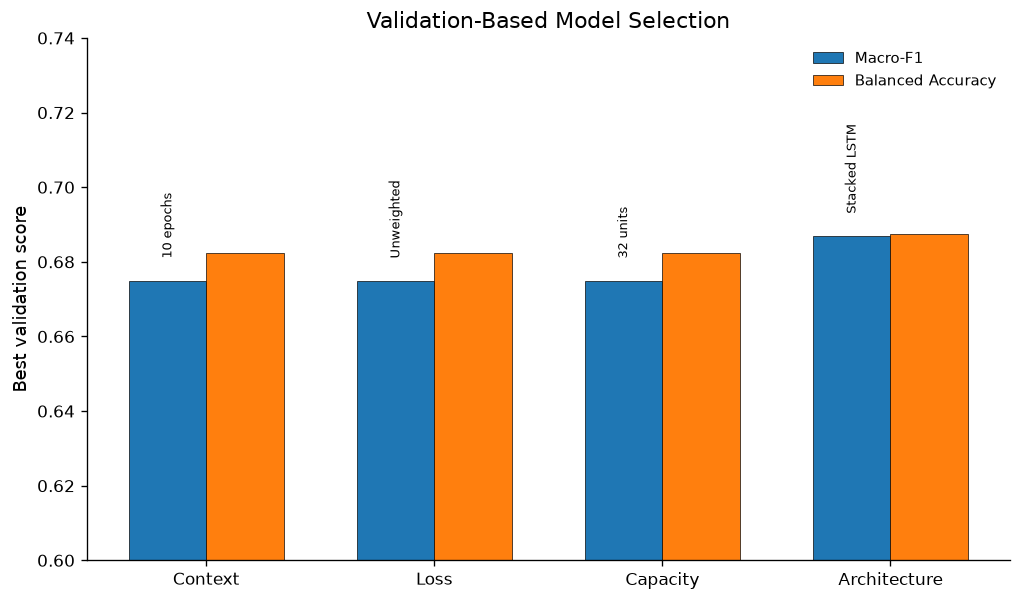

In [24]:

# This compact figure is useful as a thesis/paper summary of why the final configuration was chosen.
selection = pd.DataFrame({
    'experiment': ['Context', 'Loss', 'Capacity', 'Architecture'],
    'selected': ['10 epochs', 'Unweighted', '32 units', 'Stacked LSTM'],
    'best_macro_f1': [0.6749, 0.6749, 0.6749, 0.6869],
    'best_bal_acc': [0.6824, 0.6824, 0.6824, 0.6875],
})

fig, ax = plt.subplots(figsize=(8.4, 4.9))
x = np.arange(len(selection))
width = 0.34
ax.bar(x - width/2, selection['best_macro_f1'], width, label='Macro-F1', edgecolor='black', linewidth=0.4)
ax.bar(x + width/2, selection['best_bal_acc'], width, label='Balanced Accuracy', edgecolor='black', linewidth=0.4)
ax.set_xticks(x, selection['experiment'])
ax.set_ylabel('Best validation score')
ax.set_title('Validation-Based Model Selection')
ax.legend(frameon=False)
ax.set_ylim(0.60, 0.74)
ax.spines[['top', 'right']].set_visible(False)

for i, row in selection.iterrows():
    ax.text(i - width/2, row['best_macro_f1'] + 0.006, row['selected'], ha='center', va='bottom', fontsize=8, rotation=90)

savefig('fig12_model_selection_summary')
plt.show()



## Recommended figures for the paper

For a compact thesis/paper, the strongest figures are:

1. **Fig. 1 — Class distribution**: establishes class imbalance.
2. **Fig. 3 — Relative band power by stage**: visually connects the engineered spectral features to sleep stages.
3. **Fig. 7 — Model ablation**: documents the architecture/capacity decision.
4. **Fig. 9 — Per-stage F1**: shows where the model succeeds and where it struggles.
5. **Fig. 10 — Confusion matrix**: makes the N1→N2/REM errors explicit.
6. **Fig. 11 — ROC-AUC**: complements F1 and shows class-discrimination ability.

For the methodology section, the most useful additional figure would be a **pipeline/model architecture diagram**. This notebook intentionally does not invent a raw-EEG waveform or PSD plot because the supplied file contains engineered epoch-level features rather than the original EEG samples.

> **Important:** The validation ablation numbers are the finalized values from the experiment record. The figures are intended for presentation, not for rerunning model training.
